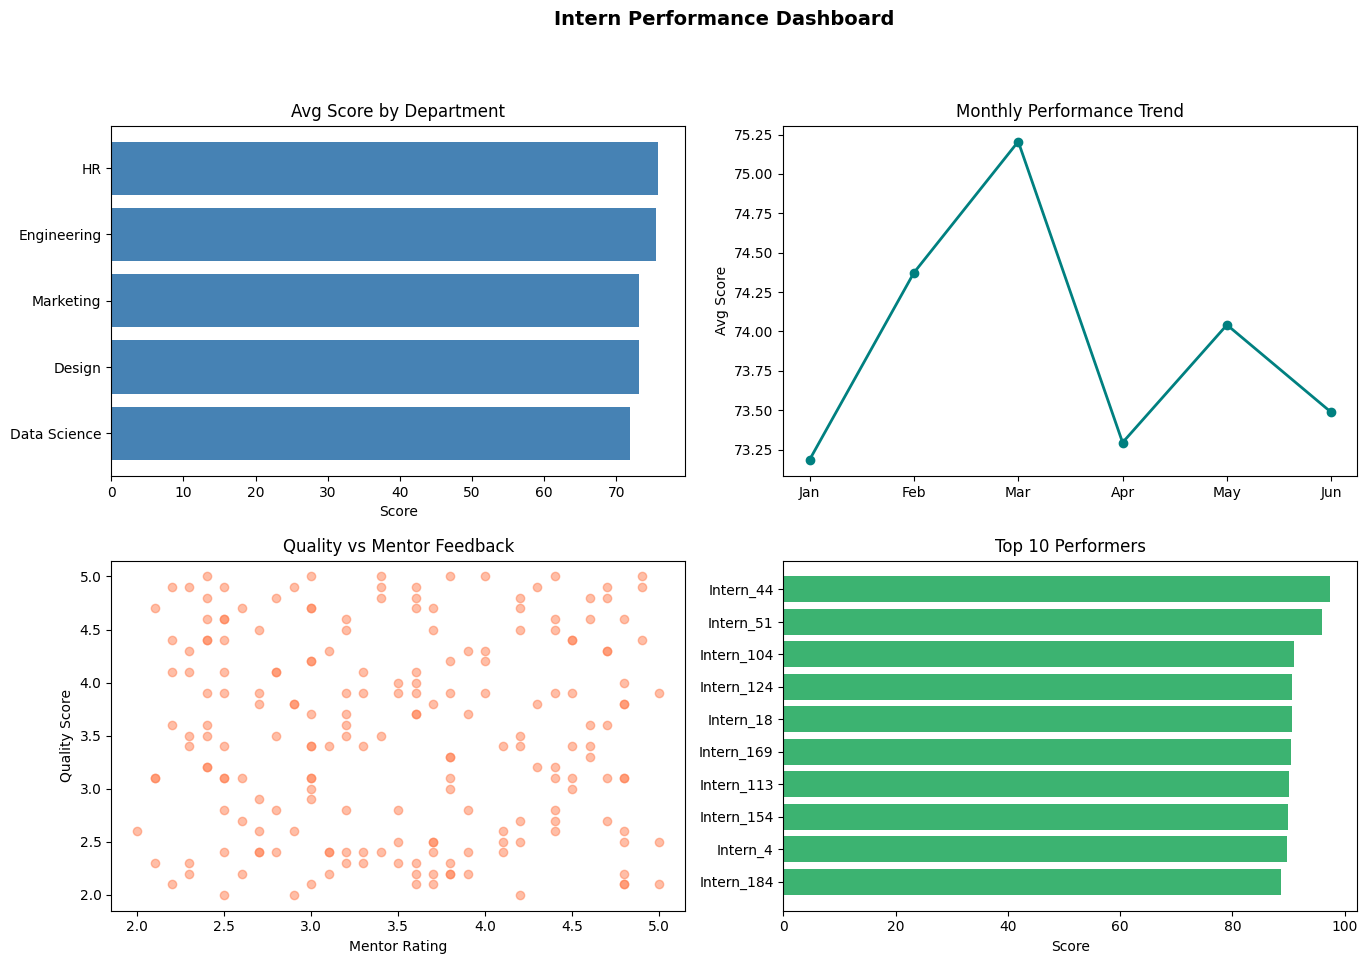

Done! ✅


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- DATA ---
np.random.seed(42)
n = 200

df = pd.DataFrame({
    'Name'       : [f'Intern_{i}' for i in range(1, n+1)],
    'Department' : np.random.choice(['Engineering', 'Data Science', 'Design', 'Marketing', 'HR'], n),
    'Month'      : np.random.choice(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'], n),
    'Task'       : np.random.randint(50, 101, n),
    'Quality'    : np.round(np.random.uniform(2.0, 5.0, n), 1),
    'Mentor'     : np.round(np.random.uniform(2.0, 5.0, n), 1),
    'Punctuality': np.random.randint(60, 101, n),
})

# --- SCORE ---
df['Score'] = (df['Task'] * 0.30 + (df['Quality']/5*100) * 0.25 +
               (df['Mentor']/5*100) * 0.25 + df['Punctuality'] * 0.20).round(1)

# CHARTS
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Intern Performance Dashboard', fontsize=14, fontweight='bold')
fig.tight_layout(pad=4)

# Chart 1 - Score by Department
dept_avg = df.groupby('Department')['Score'].mean().sort_values()
axes[0,0].barh(dept_avg.index, dept_avg.values, color='steelblue')
axes[0,0].set_title('Avg Score by Department')
axes[0,0].set_xlabel('Score')

# Chart 2 - Monthly Trend
month_order = ['Jan','Feb','Mar','Apr','May','Jun']
monthly = df.groupby('Month')['Score'].mean().reindex(month_order)
axes[0,1].plot(monthly.index, monthly.values, marker='o', color='teal', linewidth=2)
axes[0,1].set_title('Monthly Performance Trend')
axes[0,1].set_ylabel('Avg Score')

# Chart 3 - Quality vs Mentor
axes[1,0].scatter(df['Mentor'], df['Quality'], alpha=0.5, color='coral')
axes[1,0].set_title('Quality vs Mentor Feedback')
axes[1,0].set_xlabel('Mentor Rating')
axes[1,0].set_ylabel('Quality Score')

# Chart 4 - Top 10
top10 = df.nlargest(10, 'Score').sort_values('Score')
axes[1,1].barh(top10['Name'], top10['Score'], color='mediumseagreen')
axes[1,1].set_title('Top 10 Performers')
axes[1,1].set_xlabel('Score')

plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done! ✅")